# Model 07: Decision Tree Classifier

### Objective
A tree model that splits the data to predict High/Medium/Low bands. Just like the regressor, we will train a pruned tree to prevent it from overfitting the training set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('evidence', exist_ok=True)

### 1. Load Datasets & Encode Targets

In [2]:
X_train = pd.read_csv('../../../../../data/processed/X_train_scaled.csv')
y_train_raw = pd.read_csv('../../../../../data/processed/y_train_class.csv').squeeze()

X_val = pd.read_csv('../../../../../data/processed/X_val_scaled.csv')
y_val_raw = pd.read_csv('../../../../../data/processed/y_val_class.csv').squeeze()

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_val = le.transform(y_val_raw)

print("Classes:", le.classes_)
print("Datasets loaded successfully.")

Classes: ['High' 'Low' 'Medium']
Datasets loaded successfully.


### 2. Model Training

In [3]:
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

print("✅ Decision Tree Classifier Trained Successfully.")

✅ Decision Tree Classifier Trained Successfully.


### 3. Classification Evaluation

In [4]:
def evaluate_classification(model, X, y_true, model_name):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    try:
        y_prob = model.predict_proba(X)
        roc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    except AttributeError:
        roc = np.nan
        
    print(f"--- {model_name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    if not np.isnan(roc):
        print(f"ROC-AUC:  {roc:.4f}\n")
    else:
        print("ROC-AUC:  N/A\n")
        
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc, f1, roc

print("========== TRAINING SET ==========")
_, train_acc, train_f1, train_roc = evaluate_classification(dt_model, X_train, y_train, "07_decision_tree_classifier (TRAIN)")

print("========== VALIDATION SET ==========")
val_preds, val_acc, val_f1, val_roc = evaluate_classification(dt_model, X_val, y_val, "07_decision_tree_classifier (VAL)")

========== TRAINING SET ==========
--- 07_decision_tree_classifier (TRAIN) ---
Accuracy: 0.5171
F1 Score: 0.4795
ROC-AUC:  0.7147

              precision    recall  f1-score   support

        High       0.77      0.35      0.48       105
         Low       0.44      0.93      0.60       124
      Medium       0.69      0.24      0.36       121

    accuracy                           0.52       350
   macro avg       0.63      0.51      0.48       350
weighted avg       0.63      0.52      0.48       350

========== VALIDATION SET ==========
--- 07_decision_tree_classifier (VAL) ---
Accuracy: 0.2933
F1 Score: 0.2651
ROC-AUC:  0.5290

              precision    recall  f1-score   support

        High       0.19      0.38      0.26        16
         Low       0.35      0.58      0.44        24
      Medium       0.50      0.06      0.10        35

    accuracy                           0.29        75
   macro avg       0.35      0.34      0.27        75
weighted avg       0.39      0.

### 4. Confusion Matrix

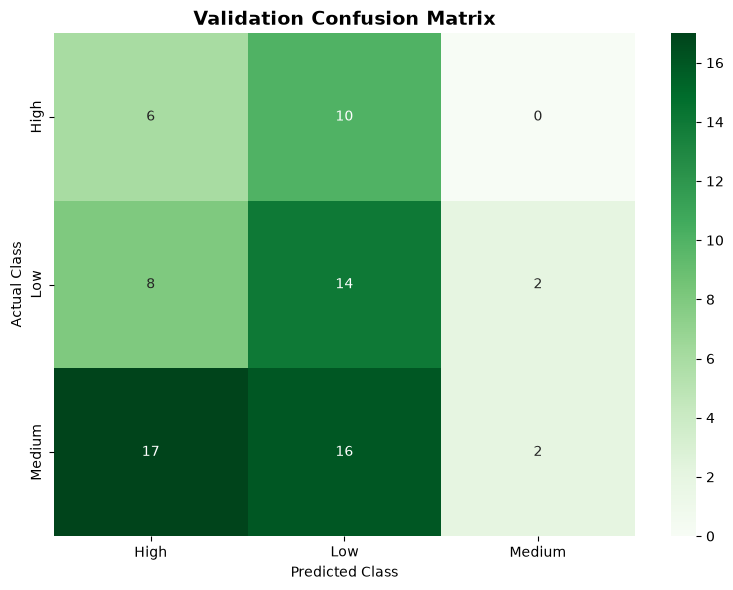

In [5]:
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.savefig('evidence/01_dt_confusion_matrix.png', dpi=300)
plt.show()

### Experiment Tracking
Automatically append the metrics of this model to our global `experiment_results.csv` matrix for the final deliverable.

In [6]:
import datetime
import os

tracker_file = '../../../../../data/processed/experiment_results.csv'
file_exists = os.path.isfile(tracker_file)

experiment_data = pd.DataFrame({
    'Timestamp': [datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
    'Model_ID': ['07_decision_tree_classifier'],
    'Model_Type': ['Classification'],
    'Val_MAE': [np.nan],
    'Val_RMSE': [np.nan],
    'Val_MAPE': [np.nan],
    'Val_R2': [np.nan],
    'Val_Accuracy': [val_acc],
    'Val_F1': [val_f1],
    'Val_ROCAUC': [val_roc]
})

experiment_data.to_csv(tracker_file, mode='a', header=not file_exists, index=False)
print(f"✅ Experiment logged successfully to {tracker_file}")

✅ Experiment logged successfully to ../../../../../data/processed/experiment_results.csv
